# Solution: Set Difference in 108 Parameters (Monthly Algorithmic Challenge, September 2026)

## 0. The task

The input is a set $X$ of four distinct symbols from $\{\mathtt{a}, \dots, \mathtt{p}\}$ and the same set with one symbol $z$ removed, $Y = X \setminus \{z\}$. Both halves are shuffled independently. The model reads

$$[\mathrm{BOS}]\; x_1\, x_2\, x_3\, x_4\; [\mathrm{SEP}]\; y_1\, y_2\, y_3\; [\mathrm{SEP}]$$

and must output $z$ at the final $\mathrm{SEP}$. Example: $\mathrm{BOS}\ \mathtt{n\,b\,j\,e}\ \mathrm{SEP}\ \mathtt{e\,n\,b}\ \mathrm{SEP} \to \mathtt{j}$.

## 1. The model, written out

Positions are numbered $0$ to $9$. Position 0 is $\mathrm{BOS}$, positions 1 to 4 hold $X$, position 5 is the first $\mathrm{SEP}$, positions 6 to 8 hold $Y$, position 9 is the final $\mathrm{SEP}$ where the answer is read.

**Residual stream.** Every token $t$ has an embedding $E_t \in \mathbb{R}^2$ and every position $j$ a positional embedding $P_j \in \mathbb{R}^2$. The residual at position $j$ starts as

$$r_j = E_{x_j} + P_j .$$

**One head with $d_{\text{head}} = 1$.** Each head has three $1 \times 2$ matrices $W_Q, W_K, W_V$, so its query, key and value are single numbers: $q_j = W_Q r_j$, $k_j = W_K r_j$, $v_j = W_V r_j$. From the final position $i = 9$ the score on position $j$ is $s_j = q_9 k_j$ (no scaling since $\sqrt{d_{\text{head}}} = 1$), the weights are the softmax $A_j = e^{s_j} / \sum_{j'} e^{s_{j'}}$, and the head's output is one scalar,

$$s_h = \sum_{j=0}^{9} A^{(h)}_j\, v^{(h)}_j = \dfrac{N_h}{Z_h}, \qquad N_h = \sum_j e^{s^{(h)}_j} v^{(h)}_j, \quad Z_h = \sum_j e^{s^{(h)}_j} .$$

**Layer and readout.** $W_O$ is $2 \times 2$; column $h$ of it, call it $a_h$, is the direction head $h$ writes along. The final residual and the logits are

$$r = r_9 + s_0\, a_0 + s_1\, a_1, \qquad \ell_t = u_t \cdot r,$$

with $u_t$ the unembedding row of token $t$. The prediction is $\arg\max_t \ell_t$ over the 16 symbols.

Parameter count: $18 \times 2$ (tokens) $+ 10 \times 2$ (positions) $+ 2 \times 3 \times 2$ (heads) $+ 4$ ($W_O$) $+ 18 \times 2$ (unembedding) $= 108$.

## 2. The algorithm in one paragraph

The final residual is a 2-D vector whose **direction** depends only on the missing symbol $z$ and whose **length** depends on the rest of the set. The 16 unembedding vectors fan out around the plane in a fixed order of symbols ($\mathtt{d}, \mathtt{a}, \mathtt{h}, \mathtt{g}, \mathtt{b}, \mathtt{k}, \mathtt{e}, \mathtt{f}, \mathtt{i}, \mathtt{o}, \mathtt{n}, \mathtt{p}, \mathtt{l}, \mathtt{c}, \mathtt{j}, \mathtt{m}$), so the direction picks the answer. The direction comes out of the attention like this. The positional embeddings are identical inside each half, so the model only sees two bags of symbols. At the final $\mathrm{SEP}$ each head attends to every symbol with a symbol-dependent weight $e_h(t)$ and reads a symbol-dependent value $v_h(t)$; a copy in the $Y$ half gets its weight multiplied by a fixed factor $\rho_h$ and its value shifted by a fixed amount $\Delta_h$. The symbol embeddings lie on exactly the curve where

$$e_h(t)\, v_h(t) + \rho_h e_h(t)\, (v_h(t) + \Delta_h) = \text{const}_h \quad \text{for every symbol } t,$$

so every symbol that appears in both halves contributes the same constant to $N_h$ whatever it is, and only $z$ (which appears once) contributes something symbol-specific. Hence $N_h = g_h(z) + C_h$ exactly, with $g_h(z) = e_h(z) v_h(z)$. The normalisers $Z_0, Z_1$ depend on the set but stay in a fixed ratio, so $(s_0, s_1)$ is a $z$-specific direction times a set-specific scale. $W_O$ maps that direction into the plane, and the fan reads it off.

The rest of the notebook shows each step with the numbers.

## Setup

In [1]:
%pip install -q torch einops huggingface_hub matplotlib

In [2]:
import json, importlib, itertools, copy
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

torch.set_grad_enabled(False)
np.set_printoptions(precision=3, suppress=True, linewidth=200)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

REPO_ID = "andyrdt/09_2026_puzzle_1"
model_py_path = hf_hub_download(REPO_ID, "model.py")
spec = importlib.util.spec_from_file_location("model", model_py_path)
model_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(model_module)
config = json.loads(Path(hf_hub_download(REPO_ID, "config.json")).read_text())
model = model_module.AttentionOnlyTransformer.from_config(config["model"])
model.load_state_dict(torch.load(hf_hub_download(REPO_ID, "model.pt"), map_location="cpu", weights_only=True))
model.eval()

NUM_SYMBOLS, SET_SIZE, BOS, SEP = 16, 4, 16, 17
SYM = [chr(97 + k) for k in range(16)]
E, P, U = model.tok_embed.weight, model.pos_embed.weight, model.unembed.weight
L = model.layers[0]
a0, a1 = L.W_O.weight[:, 0], L.W_O.weight[:, 1]
r9 = E[SEP] + P[9]
PX, PY = P[1], P[6]

def label(t):
    return SYM[t] if t < 16 else ("BOS" if t == BOS else "SEP")

def encode(X, Y):
    return [BOS] + list(X) + [SEP] + list(Y) + [SEP]

# every problem (set X, missing z) once, in canonical order: 1820 sets x 4 = 7280 prompts
PROBLEMS = []
for X in itertools.combinations(range(16), 4):
    for z in X:
        PROBLEMS.append((encode(X, [s for s in X if s != z]), z))
XALL = torch.tensor([p for p, _ in PROBLEMS]); ZALL = torch.tensor([z for _, z in PROBLEMS])
logits_all, attn_all = model(XALL)
print("parameters:", sum(p.numel() for p in model.parameters()))
print("accuracy over all 7280 problems (one ordering each):", (logits_all[:, -1, :16].argmax(-1) == ZALL).float().mean().item())

# and over 100k random orderings
rng = np.random.default_rng(0)
xs, zs = [], []
for _ in range(100000):
    X = rng.choice(16, 4, replace=False); z = int(rng.choice(X))
    Y = [s for s in X if s != z]; rng.shuffle(X); rng.shuffle(Y)
    xs.append(encode(X.tolist(), Y)); zs.append(z)
lg, _ = model(torch.tensor(xs))
print("accuracy over 100000 random orderings:", (lg[:, -1, :16].argmax(-1) == torch.tensor(zs)).float().mean().item())

parameters: 108
accuracy over all 7280 problems (one ordering each): 1.0


accuracy over 100000 random orderings: 1.0


## 3. All 108 parameters

Three facts are visible straight from the weights.

1. **The positional embeddings are identical within each half.** $P_1 = P_2 = P_3 = P_4$ and $P_6 = P_7 = P_8$. The model cannot tell the order inside a half, so it works on two bags of symbols by construction. Only three positional vectors matter: $P_X$ (the $X$ half), $P_Y$ (the $Y$ half), and the three special positions.
2. **The 16 symbol embeddings lie on a curve**, and reading along that curve gives the order $\mathtt{d}, \mathtt{a}, \mathtt{h}, \mathtt{g}, \mathtt{b}, \mathtt{k}, \mathtt{e}, \mathtt{f}, \mathtt{i}, \mathtt{o}, \mathtt{n}, \mathtt{p}, \mathtt{l}, \mathtt{c}, \mathtt{j}, \mathtt{m}$.
3. **The 16 unembedding vectors form a fan** in that same order, sweeping from $169^\circ$ ($\mathtt{d}$) clockwise to $-83^\circ$ ($\mathtt{m}$).

positional embeddings:
  P[0] = (  3.939,   0.144)
  P[1] = (  3.839,   0.380)
  P[2] = (  3.839,   0.380)
  P[3] = (  3.839,   0.380)
  P[4] = (  3.839,   0.380)
  P[5] = (  0.030,  -3.009)
  P[6] = ( -1.974,   0.044)
  P[7] = ( -1.974,   0.044)
  P[8] = ( -1.974,   0.044)
  P[9] = (  0.742,  -0.430)

heads:
  head 0: W_Q = [-0.505 -0.119]  W_K = [ 0.314 -1.484]  W_V = [16.351  1.368]
  head 1: W_Q = [-1.991 -2.762]  W_K = [ 0.235 -2.093]  W_V = [-13.022   2.909]

W_O columns (the direction each head writes along): a0 = [-20.85  10.71]  a1 = [  0.11 -15.61]

symbols in curve order: embedding angle / norm, unembedding angle / norm
  d: E angle   103.0  |E|  1.08    U angle   168.6  |U| 10.26
  a: E angle   105.9  |E|  0.99    U angle   163.5  |U|  8.66
  h: E angle   109.5  |E|  0.91    U angle   158.2  |U|  7.35
  g: E angle   113.7  |E|  0.84    U angle   152.2  |U|  6.16
  b: E angle   118.7  |E|  0.78    U angle   144.9  |U|  5.03
  k: E angle   124.7  |E|  0.72    U angle   135.9 

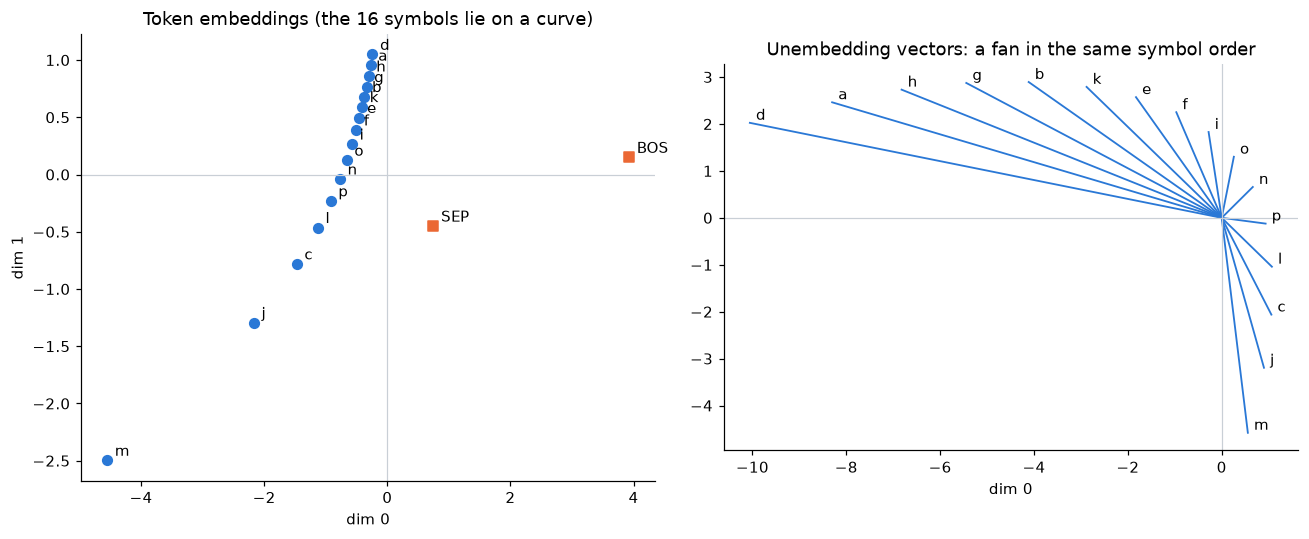

In [3]:
print("positional embeddings:")
for j in range(10):
    print(f"  P[{j}] = ({P[j,0]:7.3f}, {P[j,1]:7.3f})")
print("\nheads:")
for h in range(2):
    hd = L.heads[h]
    print(f"  head {h}: W_Q = {hd.W_Q.weight[0].numpy().round(3)}  W_K = {hd.W_K.weight[0].numpy().round(3)}  W_V = {hd.W_V.weight[0].numpy().round(3)}")
print("\nW_O columns (the direction each head writes along): a0 =", a0.numpy().round(2), " a1 =", a1.numpy().round(2))

ang = lambda v: float(torch.rad2deg(torch.atan2(v[1], v[0])))
ORDER = [SYM.index(c) for c in "dahgbkefionplcjm"]
print("\nsymbols in curve order: embedding angle / norm, unembedding angle / norm")
for t in ORDER:
    print(f"  {SYM[t]}: E angle {ang(E[t]):7.1f}  |E| {E[t].norm():5.2f}    U angle {ang(U[t]):7.1f}  |U| {U[t].norm():5.2f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(E[:16, 0], E[:16, 1], s=40, color="#2a78d6")
for t in range(16):
    ax[0].annotate(SYM[t], (E[t, 0], E[t, 1]), xytext=(5, 3), textcoords="offset points")
ax[0].scatter([E[BOS, 0], E[SEP, 0]], [E[BOS, 1], E[SEP, 1]], s=40, marker="s", color="#eb6834")
ax[0].annotate("BOS", (E[BOS, 0], E[BOS, 1]), xytext=(5, 3), textcoords="offset points"); ax[0].annotate("SEP", (E[SEP, 0], E[SEP, 1]), xytext=(5, 3), textcoords="offset points")
ax[0].axhline(0, color="#c9cfd6", lw=0.8); ax[0].axvline(0, color="#c9cfd6", lw=0.8)
ax[0].set_title("Token embeddings (the 16 symbols lie on a curve)"); ax[0].set_xlabel("dim 0"); ax[0].set_ylabel("dim 1")
for t in range(16):
    ax[1].plot([0, U[t, 0]], [0, U[t, 1]], color="#2a78d6", lw=1.2)
    ax[1].annotate(SYM[t], (U[t, 0], U[t, 1]), xytext=(4, 2), textcoords="offset points")
ax[1].set_aspect("equal"); ax[1].axhline(0, color="#c9cfd6", lw=0.8); ax[1].axvline(0, color="#c9cfd6", lw=0.8)
ax[1].set_title("Unembedding vectors: a fan in the same symbol order"); ax[1].set_xlabel("dim 0")
plt.tight_layout(); plt.show()

## 4. The final residual points in a direction that depends only on $z$

For all 7280 problems, compute the two head scalars $s_0, s_1$ and the final residual $r = r_9 + s_0 a_0 + s_1 a_1$. Coloured by the missing symbol, the residuals lie on 16 rays from the origin, one per $z$, in the fan order. Within a ray the length varies with the other three symbols, and the length does not matter because $\arg\max_t u_t \cdot r$ is unchanged by scaling $r$ by a positive number (the direct path $r_9$ has length $1.7$ against a typical $|r|$ of about $135$).

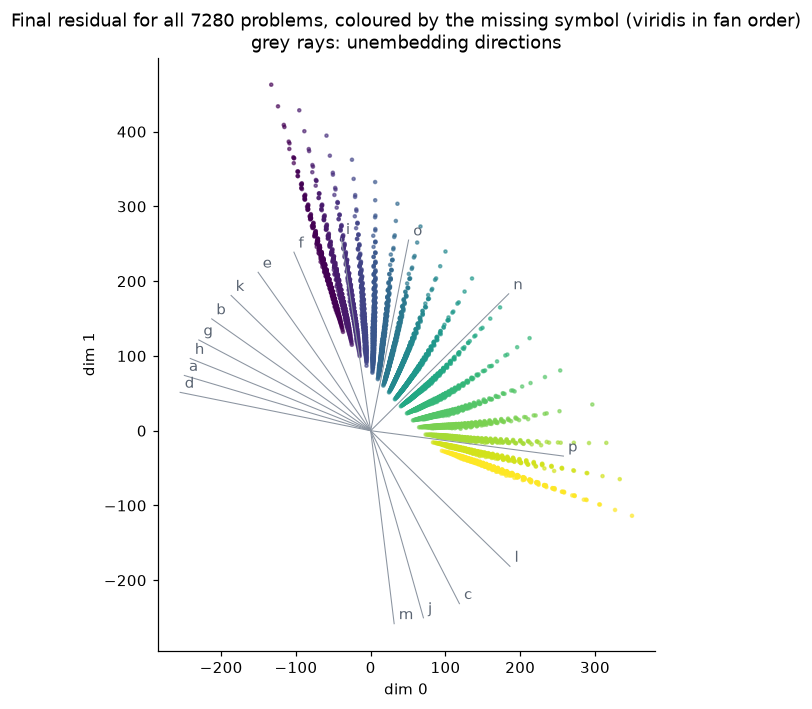

 z angle mean angle min angle max  |r| min  |r| max
 d      105.7     105.1     106.5    137.3    481.6
 a      102.2     101.7     103.4    117.7    439.1
 h       98.2      97.5      99.3    100.9    399.1
 g       93.5      92.8      94.5     87.2    363.3
 b       88.2      87.5      89.2     77.7    332.7
 k       82.1      81.4      83.5     69.7    305.7
 e       74.5      73.7      76.3     62.7    281.2
 f       64.7      63.9      67.4     56.9    259.7
 i       52.7      51.8      56.4     53.1    244.6
 o       39.2      37.6      43.6     51.9    239.1
 n       25.6      23.5      30.2     53.8    246.0
 p       13.6      11.2      17.6     58.3    266.0
 l        3.7       1.2       6.8     64.9    298.5
 c       -4.5      -6.6      -2.9     73.7    315.5
 j      -11.3     -13.1     -10.4     84.8    339.4
 m      -16.7     -18.4     -15.6     98.9    367.5


In [4]:
R = E[XALL] + P[torch.arange(10)]
S = torch.stack([(attn_all[0][:, h, -1] * (R @ L.heads[h].W_V.weight[0])).sum(-1) for h in range(2)], 1)
FINAL = r9 + S[:, :1] * a0 + S[:, 1:] * a1
assert torch.allclose(FINAL @ U.T, logits_all[:, -1], atol=1e-3)
ANG = torch.rad2deg(torch.atan2(FINAL[:, 1], FINAL[:, 0]))

idx_of = {t: i for i, t in enumerate(ORDER)}
colors = plt.cm.viridis(np.array([idx_of[int(z)] for z in ZALL]) / 15)
fig, ax = plt.subplots(figsize=(7.5, 7))
ax.scatter(FINAL[:, 0], FINAL[:, 1], s=4, c=colors, alpha=0.6)
for t in ORDER:
    d = U[t] / U[t].norm() * 260
    ax.plot([0, d[0]], [0, d[1]], color="#8c95a1", lw=0.7)
    ax.annotate(SYM[t], (d[0], d[1]), xytext=(3, 3), textcoords="offset points", color="#5a6472")
ax.set_aspect("equal"); ax.set_xlabel("dim 0"); ax.set_ylabel("dim 1")
ax.set_title("Final residual for all 7280 problems, coloured by the missing symbol (viridis in fan order)\ngrey rays: unembedding directions")
plt.show()

print(f"{'z':>2s} {'angle mean':>10s} {'angle min':>9s} {'angle max':>9s} {'|r| min':>8s} {'|r| max':>8s}")
for t in ORDER:
    sel = ZALL == t
    print(f"{SYM[t]:>2s} {ANG[sel].mean():10.1f} {ANG[sel].min():9.1f} {ANG[sel].max():9.1f} {FINAL[sel].norm(dim=1).min():8.1f} {FINAL[sel].norm(dim=1).max():8.1f}")

## 5. Where the direction comes from

### 5a. What one symbol contributes to a head

Fix a head $h$ and write $q = q_9$ for its query at the final position. For a symbol $t$ sitting in the $X$ half the residual is $E_t + P_X$, so its unnormalised weight and its value are

$$e_h(t) = \exp\!\big(q\, W_K (E_t + P_X)\big), \qquad v_h(t) = W_V (E_t + P_X).$$

The same symbol in the $Y$ half has residual $E_t + P_Y$. Because everything is linear before the exponential, moving a symbol from $X$ to $Y$ multiplies its weight by a factor and shifts its value by an amount that are **the same for every symbol**:

$$e^{Y}_h(t) = \rho_h\, e_h(t), \quad \rho_h = \exp\!\big(q\, W_K (P_Y - P_X)\big), \qquad v^{Y}_h(t) = v_h(t) + \Delta_h, \quad \Delta_h = W_V (P_Y - P_X).$$

Head 0 has $\rho_0 = 2.37$ and $\Delta_0 = -95.5$: a $Y$ copy gets 2.4 times the attention of an $X$ copy and a value about 95 lower. Head 1 has $\rho_1 = 1.43$, $\Delta_1 = +74.7$, the mirror image.

### 5b. Paired symbols contribute a constant

A symbol $y \in Y$ appears once in each half, so its total contribution to the unnormalised sum $N_h$ is

$$e_h(y)\, v_h(y) + \rho_h\, e_h(y)\, \big(v_h(y) + \Delta_h\big) = e_h(y)\,\big[(1 + \rho_h)\, v_h(y) + \rho_h \Delta_h\big].$$

The table below evaluates this for all 16 symbols. In head 0 it is $-41.2 \pm 0.3$ for every symbol; in head 1 it is $11.1 \pm 1.6$. The three paired symbols therefore add a fixed $3 \times \text{const}_h$ to $N_h$, and $\mathrm{BOS}$ and the two $\mathrm{SEP}$s add fixed amounts too. The only symbol-specific term left is the lone symbol $z$, which contributes $g_h(z) = e_h(z)\, v_h(z)$:

$$N_h = g_h(z) + C_h .$$

### 5c. Why the constant holds: the embedding curve

The pair contribution is constant iff $v_h(t) = A_h / e_h(t) + B_h$ with $(1 + \rho_h) B_h + \rho_h \Delta_h = 0$. Both $v_h(t)$ and $\log e_h(t)$ are linear functions of the 2-D embedding $E_t$, so this is a curve in the plane, and the 16 symbol embeddings sit on it ($R^2 = 0.9999$ for head 0). That is the curve visible in section 3. Training placed the symbols exactly where a repeated symbol becomes invisible.

In [5]:
print("Per symbol (curve order): unnormalised weight e and value v at an X position and at a Y position, and the pair total e_X v_X + e_Y v_Y")
for h in range(2):
    hd = L.heads[h]
    q = float(hd.W_Q.weight[0] @ r9); wk, wv = hd.W_K.weight[0], hd.W_V.weight[0]
    rho = float(torch.exp(q * (wk @ (PY - PX)))); dv = float(wv @ (PY - PX))
    print(f"\n=== head {h}:  rho = e_Y/e_X = {rho:.3f},  delta = v_Y - v_X = {dv:.1f} ===")
    print(f"{'t':>2s} {'e_X':>7s} {'v_X':>7s} {'e_Y':>7s} {'v_Y':>7s} | {'pair total':>10s} | {'lone g(t)=e_X v_X':>17s}")
    pairs, xs, ys = [], [], []
    for t in ORDER:
        eX = float(torch.exp(q * (wk @ (E[t] + PX)))); vX = float(wv @ (E[t] + PX))
        eY = float(torch.exp(q * (wk @ (E[t] + PY)))); vY = float(wv @ (E[t] + PY))
        pairs.append(eX * vX + eY * vY); xs.append(1 / eX); ys.append(vX)
        print(f"{SYM[t]:>2s} {eX:7.3f} {vX:7.1f} {eY:7.3f} {vY:7.1f} | {eX*vX+eY*vY:10.1f} | {eX*vX:17.1f}")
    print(f"pair total: mean {np.mean(pairs):.1f}, std {np.std(pairs):.2f}")
    A = np.stack([xs, np.ones(16)], 1); coef, *_ = np.linalg.lstsq(A, ys, rcond=None)
    r2 = 1 - ((A @ coef - ys) ** 2).sum() / ((np.array(ys) - np.mean(ys)) ** 2).sum()
    print(f"curve: v_X = {coef[0]:.2f} / e_X + {coef[1]:.2f}   (R^2 = {r2:.4f});   (1+rho) B + rho delta = {(1+rho)*coef[1] + rho*dv:.2f}  (0 means exact cancellation)")
    for name, tok, pos in [("BOS", BOS, 0), ("SEP@5", SEP, 5), ("SEP@9", SEP, 9)]:
        e = float(torch.exp(q * (wk @ (E[tok] + P[pos])))); v = float(wv @ (E[tok] + P[pos]))
        print(f"  {name}: e = {e:.3f}, v = {v:.1f}, e*v = {e*v:.1f}")

Per symbol (curve order): unnormalised weight e and value v at an X position and at a Y position, and the pair total e_X v_X + e_Y v_Y

=== head 0:  rho = e_Y/e_X = 2.366,  delta = v_Y - v_X = -95.5 ===
 t     e_X     v_X     e_Y     v_Y | pair total | lone g(t)=e_X v_X
 d   1.900    60.8   4.494   -34.7 |      -40.7 |             115.5
 a   1.746    60.2   4.130   -35.3 |      -41.0 |             105.0
 h   1.604    59.5   3.795   -36.0 |      -41.2 |              95.5
 g   1.478    58.8   3.497   -36.7 |      -41.3 |              87.0
 b   1.368    58.1   3.238   -37.4 |      -41.4 |              79.6
 k   1.268    57.4   2.999   -38.1 |      -41.5 |              72.8
 e   1.167    56.6   2.761   -38.9 |      -41.5 |              66.0
 f   1.063    55.6   2.514   -40.0 |      -41.4 |              59.0
 i   0.957    54.3   2.263   -41.2 |      -41.4 |              51.9
 o   0.850    52.7   2.010   -42.8 |      -41.3 |              44.8
 n   0.742    50.7   1.757   -44.9 |      -41.2 |

### 5d. $N_h$ is constant per $z$; the normalisers only rescale

Across all 7280 problems, $N_0$ varies by about $\pm 0.4$ and $N_1$ by about $\pm 2.5$ within a given $z$, against spans of 118 and 134 across the sixteen values of $z$. The normalisers $Z_0, Z_1$ do depend on which three symbols accompany $z$ (they range over a factor of about 1.5), but their ratio $Z_0 / Z_1$ stays between $0.82$ and $1.13$ because the two heads spread their attention over the same positions in nearly the same way. So

$$(s_0, s_1) = \Big(\dfrac{g_0(z) + C_0}{Z_0}, \dfrac{g_1(z) + C_1}{Z_1}\Big) \approx \dfrac{1}{Z_1}\Big(\dfrac{g_0(z) + C_0}{0.9}, \; g_1(z) + C_1\Big),$$

a $z$-specific direction times a set-specific scale. Since $g_0$ and $g_1$ move monotonically along the symbol order (see the last column of the table above), the direction sweeps monotonically around the plane, one symbol after the other.

In [6]:
Ns, Zs = [], []
for h in range(2):
    hd = L.heads[h]; q = float(hd.W_Q.weight[0] @ r9)
    e = torch.exp(q * (R @ hd.W_K.weight[0])); v = R @ hd.W_V.weight[0]
    Ns.append((e * v).sum(-1)); Zs.append(e.sum(-1))
print(f"Z0/Z1 over all problems: min {float((Zs[0]/Zs[1]).min()):.3f}  mean {float((Zs[0]/Zs[1]).mean()):.3f}  max {float((Zs[0]/Zs[1]).max()):.3f}")
print(f"{'z':>2s} {'N0':>7s} {'±':>5s} {'N1':>8s} {'±':>5s} | {'s1/s0 mean':>10s} {'std':>6s}")
for t in ORDER:
    sel = ZALL == t
    ratio = S[sel, 1] / S[sel, 0]
    print(f"{SYM[t]:>2s} {Ns[0][sel].mean():7.1f} {Ns[0][sel].std():5.1f} {Ns[1][sel].mean():8.1f} {Ns[1][sel].std():5.1f} | {ratio.mean():10.2f} {ratio.std():6.2f}")

print("\nSame missing symbol, different companions:")
for toks, z in PROBLEMS[:5]:
    i = PROBLEMS.index((toks, z))
    print(f"  {' '.join(label(t) for t in toks)}  ->  N0 {Ns[0][i]:6.1f}  Z0 {Zs[0][i]:5.2f}  N1 {Ns[1][i]:7.1f}  Z1 {Zs[1][i]:5.2f}  angle {ANG[i]:6.1f}")

Z0/Z1 over all problems: min 0.823  mean 0.898  max 1.133
 z      N0     ±       N1     ± | s1/s0 mean    std
 d    33.8   0.4   -160.3   2.5 |      -4.08   0.08
 a    23.4   0.4   -147.0   2.5 |      -5.44   0.16
 h    13.9   0.4   -134.9   2.5 |      -8.50   0.36
 g     5.4   0.4   -124.3   2.5 |     -20.34   1.82
 b    -2.0   0.4   -115.1   2.5 |      54.37  12.92
 k    -8.7   0.4   -106.8   2.5 |      10.86   0.40
 e   -15.5   0.4    -98.6   2.5 |       5.68   0.12
 f   -22.5   0.4    -90.2   2.6 |       3.59   0.06
 i   -29.6   0.4    -81.8   2.6 |       2.49   0.04
 o   -36.8   0.4    -73.5   2.6 |       1.81   0.03
 n   -44.0   0.4    -65.3   2.5 |       1.35   0.02
 p   -51.0   0.4    -57.4   2.5 |       1.03   0.02
 l   -58.1   0.4    -49.8   2.4 |       0.79   0.02
 c   -65.6   0.4    -42.1   2.3 |       0.59   0.01
 j   -73.9   0.4    -34.1   2.3 |       0.43   0.01
 m   -83.7   0.4    -26.2   2.6 |       0.29   0.02

Same missing symbol, different companions:
  BOS a b c d 

## 6. The readout: a fan of unembedding vectors

For a residual pointing at angle $\theta$, the winner is $\arg\max_t |u_t| \cos(\theta - \theta_t)$. Sweeping $\theta$ around the plane gives 16 angular cells in the fan order. The observed band of angles for each $z$ (section 4) sits inside that symbol's cell, with the smallest logit margin over all 7280 problems being $2.95$.

In [7]:
angles = torch.arange(-40, 130, 0.5)
dirs = torch.stack([torch.cos(torch.deg2rad(angles)), torch.sin(torch.deg2rad(angles))], 1)
win = (dirs @ U[:16].T).argmax(-1)
cells, start = [], 0
for i in range(1, len(angles)):
    if win[i] != win[i - 1]:
        cells.append((SYM[int(win[start])], float(angles[start]), float(angles[i - 1]))); start = i
cells.append((SYM[int(win[start])], float(angles[start]), float(angles[-1])))
print("winning symbol by direction angle:")
print("  " + ", ".join(f"{s} [{a:.0f}°..{b:.0f}°]" for s, a, b in cells))
print("observed band of residual angles per z:")
print("  " + ", ".join(f"{SYM[t]} [{ANG[ZALL == t].min():.1f}..{ANG[ZALL == t].max():.1f}]" for t in ORDER))
top2 = logits_all[:, -1, :16].topk(2, dim=-1).values
print(f"\nminimum margin (winner minus runner-up logit) over all problems: {(top2[:, 0] - top2[:, 1]).min():.2f}")
print(f"|r9| = {r9.norm():.2f}  vs  mean |r| = {FINAL.norm(dim=1).mean():.1f}")

winning symbol by direction angle:
  m [-40°..-14°], j [-14°..-8°], c [-8°..-1°], l [-0°..8°], p [8°..19°], n [20°..32°], o [32°..46°], i [46°..58°], f [59°..70°], e [70°..78°], k [78°..85°], b [86°..90°], g [91°..96°], h [96°..100°], a [100°..104°], d [104°..130°]
observed band of residual angles per z:
  d [105.1..106.5], a [101.7..103.4], h [97.5..99.3], g [92.8..94.5], b [87.5..89.2], k [81.4..83.5], e [73.7..76.3], f [63.9..67.4], i [51.8..56.4], o [37.6..43.6], n [23.5..30.2], p [11.2..17.6], l [1.2..6.8], c [-6.6..-2.9], j [-13.1..-10.4], m [-18.4..-15.6]

minimum margin (winner minus runner-up logit) over all problems: 2.95
|r9| = 1.73  vs  mean |r| = 135.4


## 7. Causal tests

1. **Push one symbol off the cancellation curve** (scale its embedding by 1.5). If the mechanism is as described, problems where that symbol is *absent* are untouched, problems where it is a *companion* (appears in both halves) break because its pair no longer contributes the shared constant, and problems where it is the *missing* symbol move its ray, which may or may not leave its cell.
2. **Remove the $X$/$Y$ positional difference** (give the $Y$ positions the $X$ positional vector, so $\rho_h = 1$ and $\Delta_h = 0$). Pairs then contribute $2 e_h v_h$, which is symbol-specific, and the answer is lost.
3. **Drop the direct path** $r_9$: nothing changes.
4. **Replace the per-head normalisation** by a shared one, or none: the direction of $(N_0, N_1)$ alone already gets about 90%; the per-head normalisation with its $0.9$ ratio is what the fan is calibrated to.

In [8]:
present = torch.zeros(len(XALL), 16, dtype=torch.bool)
for i, (p, _) in enumerate(PROBLEMS):
    for t in p[1:5]: present[i, t] = True

def acc_split(mm, t):
    lg, _ = mm(XALL); ok = lg[:, -1, :16].argmax(-1) == ZALL
    is_z = ZALL == t; comp = present[:, t] & ~is_z; absent = ~present[:, t]
    return ok[absent].float().mean().item(), ok[comp].float().mean().item(), ok[is_z].float().mean().item()

print("1. scale one symbol's embedding by 1.5 -> accuracy by that symbol's role")
print(f"   {'sym':>3s} {'absent':>7s} {'companion':>10s} {'missing':>8s}")
for ch in "dkm":
    t = SYM.index(ch); mm = copy.deepcopy(model); mm.tok_embed.weight[t] *= 1.5
    a, c, zz = acc_split(mm, t)
    print(f"   {ch:>3s} {a:7.3f} {c:10.3f} {zz:8.3f}")

mm = copy.deepcopy(model); mm.pos_embed.weight[6:9] = mm.pos_embed.weight[1]
lg, _ = mm(XALL)
print(f"\n2. Y positions given the X positional vector: accuracy = {(lg[:, -1, :16].argmax(-1) == ZALL).float().mean():.3f}  (chance = {1/16:.3f})")

heads_only = S[:, :1] * a0 + S[:, 1:] * a1
print(f"\n3. heads only, no direct path: accuracy = {((heads_only @ U[:16].T).argmax(-1) == ZALL).float().mean():.3f}")

print("\n4. normalisation variants")
for name, (d0, d1) in {"actual (N0/Z0, N1/Z1)": (Zs[0], Zs[1]), "both divided by Z0": (Zs[0], Zs[0]), "both divided by Z1": (Zs[1], Zs[1]), "no normalisation": (torch.ones_like(Zs[0]), torch.ones_like(Zs[1]))}.items():
    fin = r9 + (Ns[0] / d0)[:, None] * a0 + (Ns[1] / d1)[:, None] * a1
    print(f"   {name:24s}: accuracy = {((fin @ U[:16].T).argmax(-1) == ZALL).float().mean():.3f}")

1. scale one symbol's embedding by 1.5 -> accuracy by that symbol's role
   sym  absent  companion  missing
     d   1.000      0.067    1.000
     k   1.000      0.067    0.000
     m   1.000      0.067    1.000

2. Y positions given the X positional vector: accuracy = 0.062  (chance = 0.062)

3. heads only, no direct path: accuracy = 1.000

4. normalisation variants
   actual (N0/Z0, N1/Z1)   : accuracy = 1.000
   both divided by Z0      : accuracy = 0.912
   both divided by Z1      : accuracy = 0.914
   no normalisation        : accuracy = 0.869


## 8. The algorithm, written out

**Input.** Bags $X$ (four symbols) and $Y = X \setminus \{z\}$. Order inside a bag is invisible because $P_1 = \dots = P_4$ and $P_6 = P_7 = P_8$.

**Per-symbol numbers (fixed by the weights).** For each head $h$ and symbol $t$: an attention weight $e_h(t)$ and a value $v_h(t)$ for an $X$ copy; a $Y$ copy has weight $\rho_h e_h(t)$ and value $v_h(t) + \Delta_h$. The embeddings satisfy $e_h(t)\big[(1 + \rho_h) v_h(t) + \rho_h \Delta_h\big] = \text{const}_h$ for every $t$.

**Attention (both heads, at the final $\mathrm{SEP}$).**

$$N_h = \sum_{\text{positions}} e\, v = \underbrace{3 \cdot \text{const}_h + (\mathrm{BOS}, \mathrm{SEP}\ \text{terms})}_{C_h} + \underbrace{e_h(z)\, v_h(z)}_{g_h(z)}, \qquad Z_h = \sum_{\text{positions}} e, \qquad s_h = N_h / Z_h .$$

Companions cancel to a constant; the lone symbol is the only symbol-specific term. $Z_0 / Z_1 \approx 0.9$ regardless of the set.

**Output and readout.**

$$r \approx s_0 a_0 + s_1 a_1 \propto \big(g_0(z) + C_0\big) a_0 / 0.9 + \big(g_1(z) + C_1\big) a_1, \qquad \hat z = \arg\max_t u_t \cdot r .$$

The direction of $r$ walks monotonically around the plane along the symbol order $\mathtt{d}, \mathtt{a}, \mathtt{h}, \mathtt{g}, \mathtt{b}, \mathtt{k}, \mathtt{e}, \mathtt{f}, \mathtt{i}, \mathtt{o}, \mathtt{n}, \mathtt{p}, \mathtt{l}, \mathtt{c}, \mathtt{j}, \mathtt{m}$ as $z$ does, and the unembedding fan, laid out in the same order, returns $z$.

In short: the model turns "which symbol appears once" into an angle. Repeated symbols are made invisible by placing the embeddings on the one curve where an $X$ copy plus a $Y$ copy always sum to the same number, two heads turn the lone symbol's number into a 2-D direction, and sixteen unembedding vectors fanned around the circle read the direction off.